In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tarfile
import os

# Cambia esta ruta al lugar donde subiste tu archivo en Drive
tgz_path = '/content/drive/MyDrive/2026-1/visual/rgbd_dataset_freiburg1_xyz.tgz'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tgz_path, 'r:gz') as tar:
    tar.extractall(extract_path)

print("Archivos extraídos:")
os.listdir(extract_path)

/tmp/ipykernel_3123/2919314136.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Archivos extraídos:


['rgbd_dataset_freiburg1_xyz']

In [5]:
!pip install opencv-python-headless matplotlib numpy

In [6]:
import os

dataset_root = '/content/dataset'

# Busca la carpeta rgb
for root, dirs, files in os.walk(dataset_root):
    print(root)
    if len(files) > 0:
        print(f"  → {len(files)} archivos, ej: {files[0]}")
    break

/content/dataset


In [7]:
import cv2
import numpy as np
import os

def cargar_frames(rgb_folder, max_frames=200):
    """Carga frames de la carpeta rgb/ en orden cronológico"""
    imagenes = sorted([
        f for f in os.listdir(rgb_folder)
        if f.endswith('.png') or f.endswith('.jpg')
    ])

    frames = []
    for nombre in imagenes[:max_frames]:
        ruta = os.path.join(rgb_folder, nombre)
        img = cv2.imread(ruta)
        if img is not None:
            frames.append(img)

    print(f"Frames cargados: {len(frames)}")
    return frames

# Ajusta la subcarpeta según tu dataset
rgb_folder = '/content/dataset/rgbd_dataset_freiburg1_xyz/rgb'   # o la ruta que arroje el paso 3
frames = cargar_frames(rgb_folder, max_frames=300)

Frames cargados: 300


In [8]:
def emparejar_frames(frame1, frame2):
    """Detecta puntos ORB y los empareja entre dos frames"""
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return None, None, None, None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Solo los mejores matches
    buenos = matches[:100]

    pts1 = np.float32([kp1[m.queryIdx].pt for m in buenos])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in buenos])

    return pts1, pts2, kp1, buenos

pts1, pts2, kp1, matches = emparejar_frames(frames[0], frames[1])
print(f"Puntos emparejados: {len(matches)}")

Puntos emparejados: 100


In [9]:
def estimar_trayectoria(frames, focal=525.0):
    """
    Estima la trayectoria 2D usando odometría visual.
    focal=525.0 es el valor típico para datasets TUM RGB-D.
    """
    h, w = frames[0].shape[:2]
    pp = (w / 2, h / 2)  # punto principal (centro de imagen)

    # Pose inicial
    R_total = np.eye(3)
    t_total = np.zeros((3, 1))
    trayectoria = [(0.0, 0.0)]  # (x, z)

    for i in range(1, len(frames)):
        pts1, pts2, _, _ = emparejar_frames(frames[i-1], frames[i])

        if pts1 is None or len(pts1) < 8:
            # Si no hay suficientes puntos, asume sin movimiento
            trayectoria.append(trayectoria[-1])
            continue

        E, mask = cv2.findEssentialMat(
            pts1, pts2,
            focal=focal, pp=pp,
            method=cv2.RANSAC, prob=0.999, threshold=1.0
        )

        if E is None:
            trayectoria.append(trayectoria[-1])
            continue

        _, R, t, mask = cv2.recoverPose(E, pts1, pts2, focal=focal, pp=pp)

        # Acumular transformación
        t_total = t_total + R_total @ t
        R_total = R @ R_total

        trayectoria.append((float(t_total[0]), float(t_total[2])))

        if i % 50 == 0:
            print(f"Frame {i}/{len(frames)} procesado")

    return trayectoria

trayectoria = estimar_trayectoria(frames, focal=525.0)
print(f"Trayectoria estimada: {len(trayectoria)} puntos")

/tmp/ipykernel_3123/3965696991.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trayectoria.append((float(t_total[0]), float(t_total[2])))


Frame 50/300 procesado
Frame 100/300 procesado
Frame 150/300 procesado
Frame 200/300 procesado
Frame 250/300 procesado
Trayectoria estimada: 300 puntos


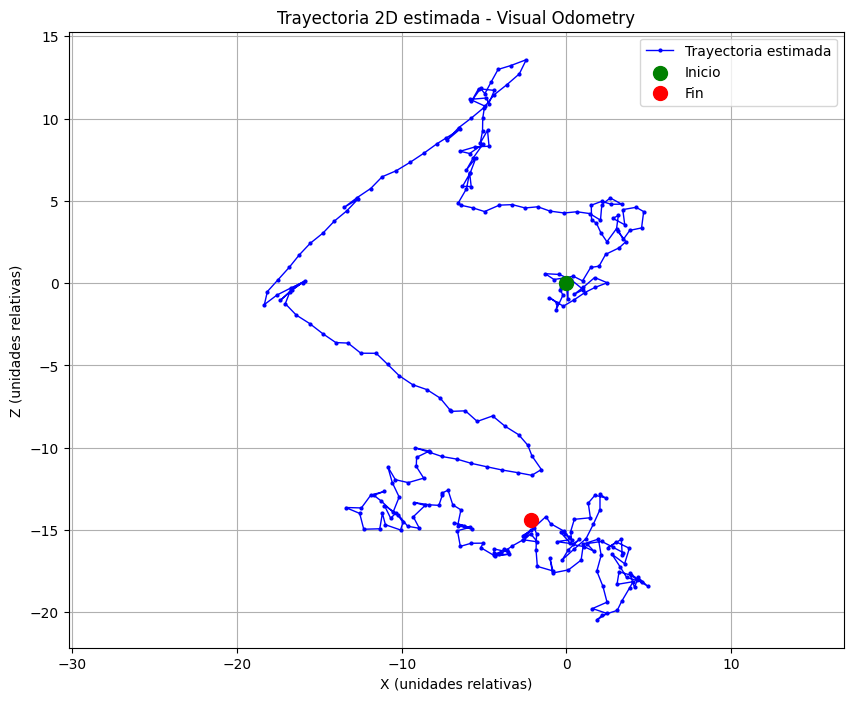

Guardada como trayectoria.png


In [10]:
import matplotlib.pyplot as plt

def graficar_trayectoria(trayectoria):
    xs = [p[0] for p in trayectoria]
    zs = [p[1] for p in trayectoria]

    plt.figure(figsize=(10, 8))
    plt.plot(xs, zs, '-o', markersize=2, linewidth=1, color='blue', label='Trayectoria estimada')
    plt.scatter(xs[0], zs[0], color='green', s=100, zorder=5, label='Inicio')
    plt.scatter(xs[-1], zs[-1], color='red', s=100, zorder=5, label='Fin')
    plt.title('Trayectoria 2D estimada - Visual Odometry')
    plt.xlabel('X (unidades relativas)')
    plt.ylabel('Z (unidades relativas)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.savefig('trayectoria.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Guardada como trayectoria.png")

graficar_trayectoria(trayectoria)

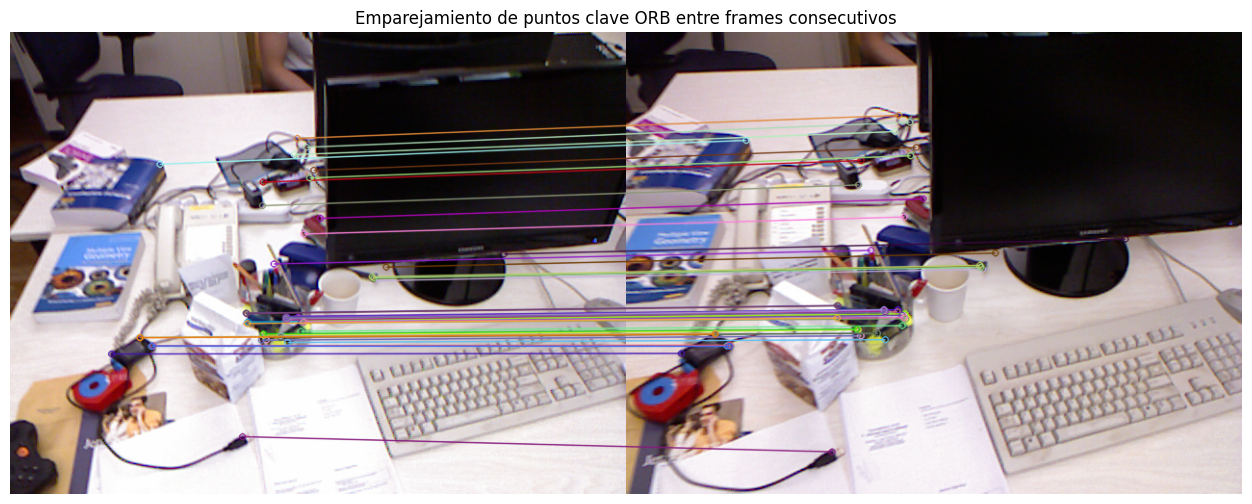

Guardada como matches.png


In [11]:
from matplotlib import pyplot as plt

def visualizar_matches(frame1, frame2, num_frames=2):
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=500)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)[:50]

    img_matches = cv2.drawMatches(
        frame1, kp1, frame2, kp2, matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    img_matches_rgb = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 6))
    plt.imshow(img_matches_rgb)
    plt.title('Emparejamiento de puntos clave ORB entre frames consecutivos')
    plt.axis('off')
    plt.savefig('matches.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Guardada como matches.png")

# Usa un par de frames con movimiento visible (ej: frames 10 y 20)
visualizar_matches(frames[10], frames[20])